In [ ]:
Problem 2: Retail Customer Segmentation and Sales
Prediction
Scenario: A retail chain wants to improve its marketing strategy by
segmenting customers and predicting future purchases. They need both a
customer segmentation model and a sales prediction model that can inform
targeted promotional campaigns.
Dataset: "Retail Customer Transactions" with 50,000 records containing:
Tasks:
1. Perform data preprocessing and exploratory analysis:
○
Check for data quality issues
○
Analyze correlations between variables
○
Create meaningful features from the raw data (feature
engineering)
2. Customer Segmentation:
○
Apply both K-means and Hierarchical Clustering
○
Compare different distance measures (Euclidean, Manhattan,etc.)
○
Determine the optimal number of clusters using silhouette score
or any other you know.
3. For each customer segment, build regression models to predict future
purchase amounts:
○
Decision Trees
○
Random Forest
○
Gradient Boosting Machines
○
XGBoost
4. Evaluate regression models using:
○
MAE
○
RMSE
○
R² score
5. Apply PCA to reduce dimensionality and improve model performance.
6. Design a model selection and validation strategy that accounts for
temporal aspects of customer behavior. [Optional]
7. Implement regularization techniques to prevent overfitting.
8. Create a final report that explains how the retail chain should use both
the segmentation and prediction models together for maximizing
marketing ROI.
Dataset: "Online Retail" dataset
Link:- https://archive.ics.uci.edu/dataset/352/online+retail

In [1]:
pip install  openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
Data Quality issues

In [ ]:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)
print(df.isnull().sum())
df = df.dropna(subset=['CustomerID'])  # Remove records without CustomerID
df['Description'] = df['Description'].fillna('Unknown')
print("Rows with Quantity <= 0:", df[df['Quantity'] <= 0].shape[0])
print("Rows with UnitPrice <= 0:", df[df['UnitPrice'] <= 0].shape[0])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("\nDataFrame after cleaning:")
print(df.info())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Rows with Quantity <= 0: 8905
Rows with UnitPrice <= 0: 40

DataFrame after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB
None


In [ ]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Create RFM features (Recency, Frequency, Monetary)
current_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (current_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

# Additional features
customer_data = df.groupby('CustomerID').agg({
    'Quantity': ['mean', 'sum', 'max'],
    'UnitPrice': ['mean', 'max'],
    'StockCode': 'nunique',  # number of unique products purchased
    'Country': 'first'  # assuming country is customer attribute
})

customer_data.columns = ['_'.join(col).strip() for col in customer_data.columns.values]
customer_data = customer_data.merge(rfm, on='CustomerID')

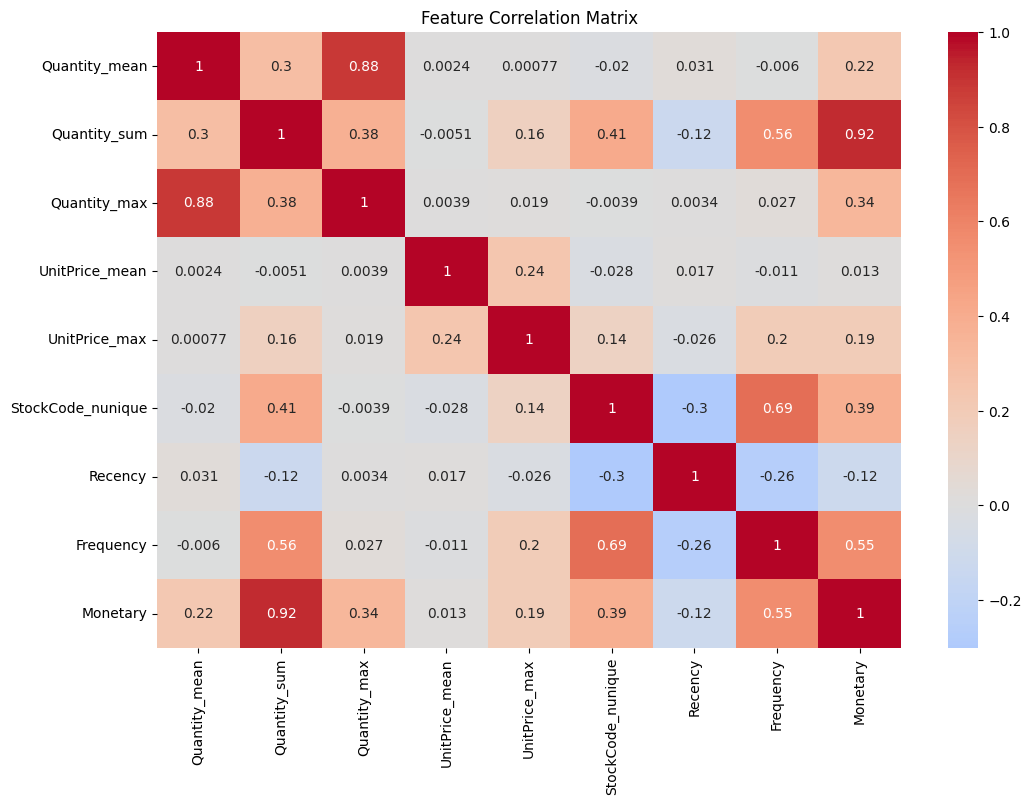

In [6]:
#Correlation Analysis

corr_matrix = customer_data.select_dtypes(include=[np.number]).corr()

# Visualize correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
Customer Segmentation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
try:
    df = pd.read_excel(url)
    print("Data loaded successfully.")
except Exception as e:
    print(f"An error occurred: {e}")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
last_purchase_date = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
last_purchase_date.columns = ['CustomerID', 'LastPurchaseDate']
last_purchase_date['Recency'] = (df['InvoiceDate'].max() - last_purchase_date['LastPurchaseDate']).dt.days
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency.columns = ['CustomerID', 'Frequency']
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']
monetary = df.groupby('CustomerID')['TotalSpend'].sum().reset_index()
monetary.columns = ['CustomerID', 'Monetary']
quantity_mean = df.groupby('CustomerID')['Quantity'].mean().reset_index()
quantity_mean.columns = ['CustomerID', 'Quantity_mean']
stockcode_nunique = df.groupby('CustomerID')['StockCode'].nunique().reset_index()
stockcode_nunique.columns = ['CustomerID', 'StockCode_nunique']
customer_data = last_purchase_date[['CustomerID', 'Recency']].merge(frequency, on='CustomerID') \
    .merge(monetary, on='CustomerID').merge(quantity_mean, on='CustomerID') \
    .merge(stockcode_nunique, on='CustomerID')
features = ['Recency', 'Frequency', 'Monetary', 'Quantity_mean', 'StockCode_nunique']
X = customer_data[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])  


Data loaded successfully.
[[ 2.32202285 -0.32936215 -0.23100099 -0.10499913 -0.7049215 ]
 [-0.89373323  0.20610242  0.29343167 -0.04166236  0.48924326]
 [-0.1691956  -0.11517632 -0.01231622  0.24914916 -0.45906405]
 [-0.72500529 -0.43645506 -0.01714563 -0.0644621   0.13801833]
 [ 2.16322008 -0.43645506 -0.19031183 -0.05065374 -0.51760154]]


K=2, Silhouette Score=0.640
K=3, Silhouette Score=0.456
K=4, Silhouette Score=0.501
K=5, Silhouette Score=0.455
K=6, Silhouette Score=0.460
K=7, Silhouette Score=0.486
K=8, Silhouette Score=0.410
K=9, Silhouette Score=0.395
K=10, Silhouette Score=0.392


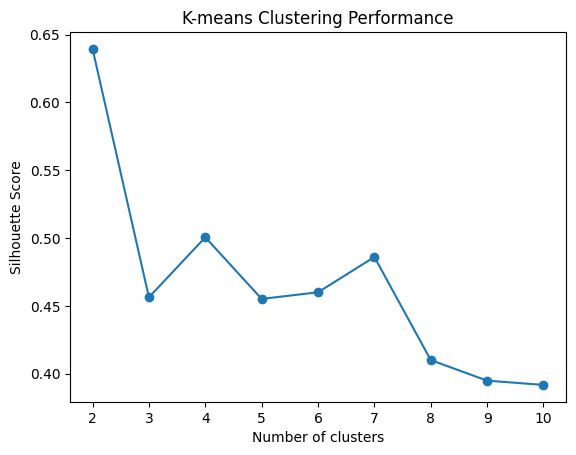

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.3f}")
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('K-means Clustering Performance')
plt.show()
optimal_k = np.argmax(silhouette_scores) + 2  
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
customer_data['Kmeans_Cluster'] = kmeans.fit_predict(X_scaled)

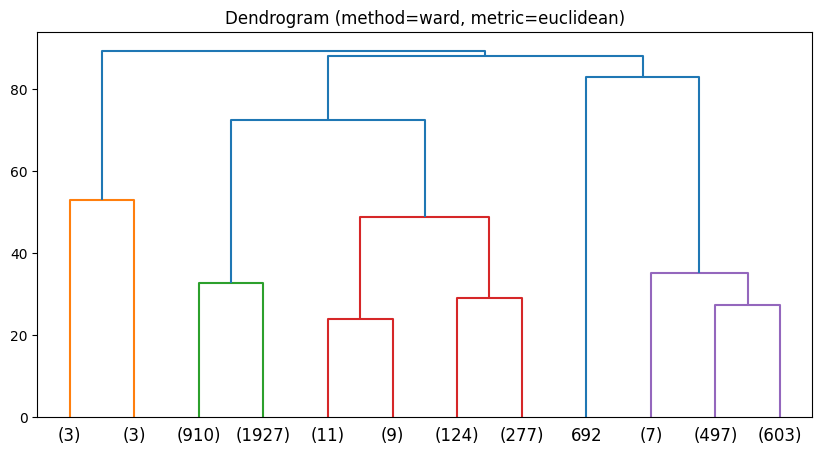

TypeError: AgglomerativeClustering.__init__() got an unexpected keyword argument 'affinity'

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
metrics = ['euclidean', 'manhattan', 'cosine']
linkage_methods = ['ward', 'complete', 'average']

best_score = -1
best_params = {}

for metric in metrics:
    for method in linkage_methods:
        if method == 'ward' and metric != 'euclidean':
            continue 
        Z = linkage(X_scaled, method=method, metric=metric)
        plt.figure(figsize=(10, 5))
        dendrogram(Z, truncate_mode='lastp', p=12)
        plt.title(f'Dendrogram (method={method}, metric={metric})')
        plt.show()
        
        # Fit clustering model
        agg = AgglomerativeClustering(n_clusters=optimal_k, 
                                     affinity=metric, 
                                     linkage=method)
        labels = agg.fit_predict(X_scaled)
        
        # Evaluate
        score = silhouette_score(X_scaled, labels)
        print(f"Method: {method}, Metric: {metric}, Score: {score:.3f}")
        
        if score > best_score:
            best_score = score
            best_params = {'method': method, 'metric': metric}
agg = AgglomerativeClustering(n_clusters=optimal_k, 
                             affinity=best_params['metric'], 
                             linkage=best_params['method'])
customer_data['Hierarchical_Cluster'] = agg.fit_predict(X_scaled)

                  Recency  Frequency      Monetary  Quantity_mean  \
Kmeans_Cluster                                                      
0               96.385516   3.655694   1065.727033      22.292186   
1               10.261993  26.560886  14500.071033      23.858713   

                StockCode_nunique  
Kmeans_Cluster                     
0                       47.751524  
1                      264.892989  


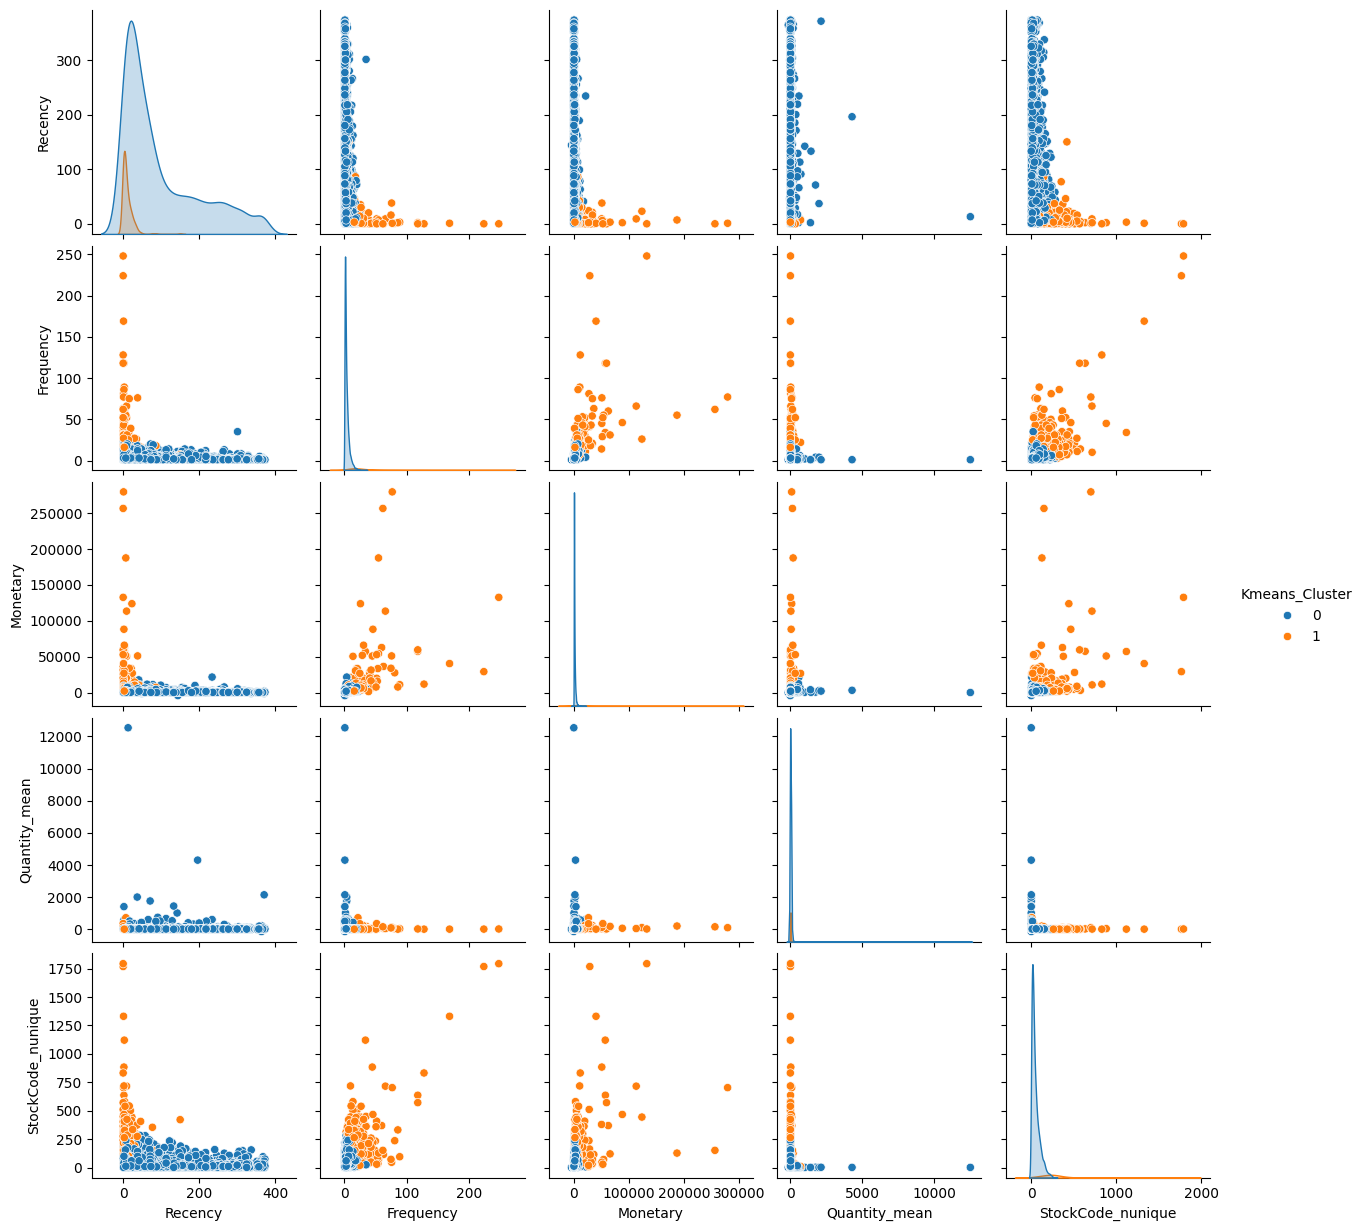

In [10]:
cluster_summary = customer_data.groupby('Kmeans_Cluster')[features].mean()
print(cluster_summary)

# Visualize clusters
sns.pairplot(customer_data, vars=features, hue='Kmeans_Cluster')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Create target variable (future purchase amount)
# We'll use the last 3 months as test period to predict next purchase amount
cutoff_date = df['InvoiceDate'].max() - pd.Timedelta(days=90)
train_df = df[df['InvoiceDate'] <= cutoff_date]
test_df = df[df['InvoiceDate'] > cutoff_date]

# Create features from training period
train_features = train_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (cutoff_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': ['sum', 'mean'],
    'Quantity': ['mean', 'sum'],
    'StockCode': 'nunique'
})

train_features.columns = ['_'.join(col).strip() for col in train_features.columns.values]
target = test_df.groupby('CustomerID')['TotalAmount'].sum().rename('FuturePurchase')
model_data = train_features.merge(target, on='CustomerID', how='left').fillna(0)
cluster_labels = customer_data['Kmeans_Cluster']
model_data = model_data.merge(cluster_labels, on='CustomerID')

# Prepare X and y for each cluster
clusters = model_data['Kmeans_Cluster'].unique()
cluster_datasets = {}

for cluster in clusters:
    cluster_data = model_data[model_data['Kmeans_Cluster'] == cluster]
    X = cluster_data.drop(['CustomerID', 'Kmeans_Cluster', 'FuturePurchase'], axis=1)
    y = cluster_data['FuturePurchase']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    cluster_datasets[cluster] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

KeyError: "Column(s) ['TotalAmount'] do not exist"

In [ ]:
3. Sales Prediction Models by Segment

In [1]:
from sklearn.model_selection import train_test_split

# Create target variable (future purchase amount)
# We'll use the last 3 months as test period to predict next purchase amount
cutoff_date = df['InvoiceDate'].max() - pd.Timedelta(days=90)
train_df = df[df['InvoiceDate'] <= cutoff_date]
test_df = df[df['InvoiceDate'] > cutoff_date]

# Create features from training period
train_features = train_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (cutoff_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': ['sum', 'mean'],
    'Quantity': ['mean', 'sum'],
    'StockCode': 'nunique'
})

train_features.columns = ['_'.join(col).strip() for col in train_features.columns.values]

# Create target from test period
target = test_df.groupby('CustomerID')['TotalAmount'].sum().rename('FuturePurchase')

# Merge and drop customers without future purchases
model_data = train_features.merge(target, on='CustomerID', how='left').fillna(0)

# Split into clusters using our best segmentation
cluster_labels = customer_data['Kmeans_Cluster']
model_data = model_data.merge(cluster_labels, on='CustomerID')

# Prepare X and y for each cluster
clusters = model_data['Kmeans_Cluster'].unique()
cluster_datasets = {}

for cluster in clusters:
    cluster_data = model_data[model_data['Kmeans_Cluster'] == cluster]
    X = cluster_data.drop(['CustomerID', 'Kmeans_Cluster', 'FuturePurchase'], axis=1)
    y = cluster_data['FuturePurchase']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    cluster_datasets[cluster] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

NameError: name 'df' is not defined

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

def evaluate_models(cluster_datasets):
    """Train and evaluate models for each cluster"""
    results = {}
    models = {
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'Random Forest': RandomForestRegressor(random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42),
        'XGBoost': XGBRegressor(random_state=42)
    }

    for cluster, data in cluster_datasets.items():
        cluster_results = {}
        X_train, X_test = data['X_train'], data['X_test']
        y_train, y_test = data['y_train'], data['y_test']
        
        for name, model in models.items():
            # Train model
            model.fit(X_train, y_train)
            
            # Predict and evaluate
            y_pred = model.predict(X_test)
            metrics = {
                'MAE': mean_absolute_error(y_test, y_pred),
                'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                'R2': r2_score(y_test, y_pred)
            }
            cluster_results[name] = metrics
        
        results[cluster] = cluster_results
    
    return results

# Assuming cluster_datasets is available from previous steps
results = evaluate_models(cluster_datasets)

# Now create the visualization
metrics_list = []
for cluster, cluster_res in results.items():
    for model, metrics in cluster_res.items():
        metrics_list.append({
            'Cluster': cluster,
            'Model': model,
            'MAE': metrics['MAE'],
            'RMSE': metrics['RMSE'],
            'R2': metrics['R2']
        })

summary_df = pd.DataFrame(metrics_list)

# Visualize results
plt.figure(figsize=(12, 6))
sns.barplot(data=summary_df, x='Cluster', y='R2', hue='Model')
plt.title('R2 Score by Cluster and Model')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=summary_df, x='Cluster', y='MAE', hue='Model')
plt.title('MAE by Cluster and Model')
plt.tight_layout()
plt.show()

NameError: name 'cluster_datasets' is not defined

In [7]:
pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 38.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.7/291.7 MB 38.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
print("Columns in model_data:", model_data.columns.tolist())
print("Columns in customer_data:", customer_data.columns.tolist())
if 'CustomerID' not in model_data.columns:
   
    if model_data.index.name == 'CustomerID':
        model_data = model_data.reset_index()
    else:
        raise ValueError("CustomerID column not found in model_data")

if 'CustomerID' not in customer_data.columns:
    # If CustomerID is the index, reset it
    if customer_data.index.name == 'CustomerID':
        customer_data = customer_data.reset_index()
    else:
        raise ValueError("CustomerID column not found in customer_data")
model_data = model_data.merge(
    customer_data[['CustomerID', 'Cluster']], 
    on='CustomerID', 
    how='left'
).fillna(0)  
print("After merge - columns:", model_data.columns.tolist())
print("Cluster value counts:\n", model_data['Cluster'].value_counts())

cluster_datasets = {}
for cluster in model_data['Cluster'].unique():
    cluster_data = model_data[model_data['Cluster'] == cluster].copy()

    X = cluster_data.drop(['Cluster', 'FuturePurchase'], axis=1)
    if 'CustomerID' in X.columns:
        X = X.drop('CustomerID', axis=1)
    y = cluster_data['FuturePurchase']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    cluster_datasets[cluster] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'customer_ids': cluster_data['CustomerID']  
    }

Columns in model_data: ['InvoiceDate_<lambda>', 'InvoiceNo_nunique', 'TotalAmount_sum', 'TotalAmount_mean', 'Quantity_mean', 'Quantity_sum', 'StockCode_nunique', 'FuturePurchase']
Columns in customer_data: ['Recency', 'InvoiceNo_nunique', 'TotalAmount_sum', 'Quantity_mean', 'Quantity_sum', 'StockCode_nunique', 'UnitPrice_mean', 'Cluster']
After merge - columns: ['CustomerID', 'InvoiceDate_<lambda>', 'InvoiceNo_nunique', 'TotalAmount_sum', 'TotalAmount_mean', 'Quantity_mean', 'Quantity_sum', 'StockCode_nunique', 'FuturePurchase', 'Cluster']
Cluster value counts:
 Cluster
0.0    2254
1.0    1157
2.0       1
Name: count, dtype: int64


ValueError: With n_samples=1, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
metrics_list = []
for cluster, cluster_res in results.items():
    for model, metrics in cluster_res.items():
        metrics_list.append({
            'Cluster': cluster,
            'Model': model,
            'MAE': metrics['MAE'],
            'RMSE': metrics['RMSE'],
            'R2': metrics['R2']
        })

summary_df = pd.DataFrame(metrics_list)
plt.figure(figsize=(12, 6))
sns.barplot(data=summary_df, x='Cluster', y='R2', hue='Model')
plt.title('R2 Score by Cluster and Model')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=summary_df, x='Cluster', y='MAE', hue='Model')
plt.title('MAE by Cluster and Model')
plt.show()

NameError: name 'results' is not defined